In [1]:
import pandas as pd
df = pd.read_csv('sensor_readings_4.csv')
df.head()

,1.687,0.445,2.332,0.429,Slight-Right-Turn
0,1.687,0.449,2.332,0.429,Slight-Right-Turn
1,1.687,0.449,2.334,0.429,Slight-Right-Turn
2,1.687,0.449,2.334,0.429,Slight-Right-Turn
3,1.687,0.449,2.334,0.429,Slight-Right-Turn
4,1.686,0.446,2.334,0.430,Slight-Right-Turn


In [2]:
df.describe()

,1.687,0.445,2.332,0.429
count,5455.000000,5455.000000,5455.000000,5455.000000
mean,1.290234,0.681313,1.881736,1.273844
std,0.626734,0.342611,0.562551,0.821746
min,0.495000,0.340000,0.836000,0.367000
25%,0.826000,0.495000,1.472000,0.788000
50%,1.089000,0.612000,1.753000,1.067000
75%,1.518500,0.753000,2.138500,1.401000
max,5.000000,5.000000,5.000000,5.000000


In [3]:
df.isnull().sum()

,0
1.687,0
0.445,0
2.332,0
0.429,0
Slight-Right-Turn,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5455 entries, 0 to 5454
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   1.687              5455 non-null   float64
 1   0.445              5455 non-null   float64
 2   2.332              5455 non-null   float64
 3   0.429              5455 non-null   float64
 4   Slight-Right-Turn  5455 non-null   object 
dtypes: float64(4), object(1)
memory usage: 213.2+ KB


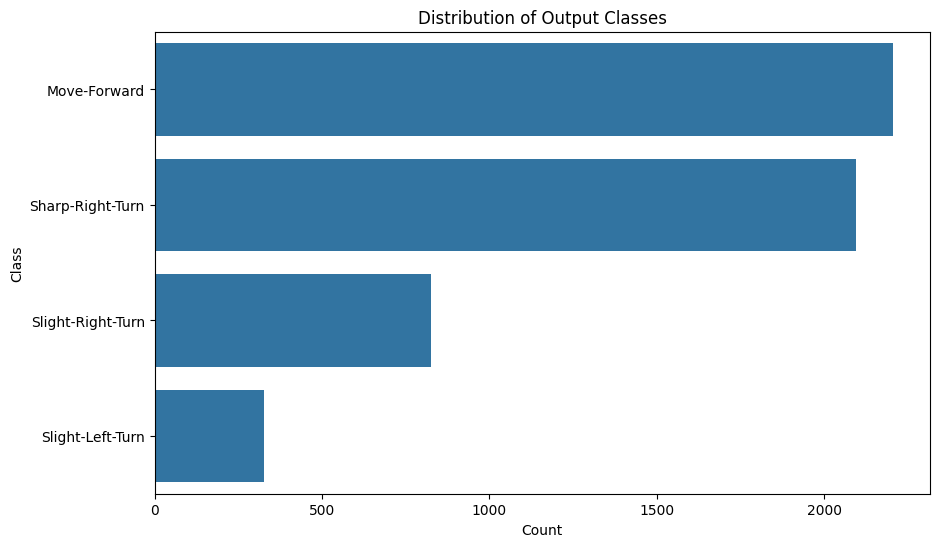

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming the last column 'Slight-Right-Turn' contains the output classes
plt.figure(figsize=(10, 6))
sns.countplot(y='Slight-Right-Turn', data=df, order=df['Slight-Right-Turn'].value_counts().index)
plt.title('Distribution of Output Classes')
plt.xlabel('Count')
plt.ylabel('Class')
plt.show()

In [6]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Encode the 'Slight-Right-Turn' column and create a new column 'encoded_output'
df['encoded_output'] = le.fit_transform(df['Slight-Right-Turn'])

# Display the DataFrame with the new encoded column
df.head()

,1.687,0.445,2.332,0.429,Slight-Right-Turn,encoded_output
0,1.687,0.449,2.332,0.429,Slight-Right-Turn,3
1,1.687,0.449,2.334,0.429,Slight-Right-Turn,3
2,1.687,0.449,2.334,0.429,Slight-Right-Turn,3
3,1.687,0.449,2.334,0.429,Slight-Right-Turn,3
4,1.686,0.446,2.334,0.430,Slight-Right-Turn,3


In [7]:
df.head()

,1.687,0.445,2.332,0.429,Slight-Right-Turn,encoded_output
0,1.687,0.449,2.332,0.429,Slight-Right-Turn,3
1,1.687,0.449,2.334,0.429,Slight-Right-Turn,3
2,1.687,0.449,2.334,0.429,Slight-Right-Turn,3
3,1.687,0.449,2.334,0.429,Slight-Right-Turn,3
4,1.686,0.446,2.334,0.430,Slight-Right-Turn,3


In [8]:
df = df.drop('Slight-Right-Turn', axis=1)

In [9]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df.drop('encoded_output', axis=1)
y = df['encoded_output']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4364, 4)
X_test shape: (1091, 4)
y_train shape: (4364,)
y_test shape: (1091,)


In [10]:
def cap_outliers_iqr(df_features):
    df_capped = df_features.copy()
    for column in df_capped.columns:
        Q1 = df_capped[column].quantile(0.25)
        Q3 = df_capped[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_capped[column] = df_capped[column].clip(lower=lower_bound, upper=upper_bound)
    return df_capped

# Apply the outlier capping to X_train and X_test
X_train_capped = cap_outliers_iqr(X_train)
X_test_capped = cap_outliers_iqr(X_test)

# Update X_train and X_test to use the capped data
X_train = X_train_capped
X_test = X_test_capped

print("Outliers handled in X_train and X_test using IQR capping.")
print("X_train head after outlier capping:")
print(X_train.head())
print("\nX_test head after outlier capping:")
print(X_test.head())

Outliers handled in X_train and X_test using IQR capping.
X_train head after outlier capping:
      1.687   0.445  2.332  0.429
5046  1.226  0.5740  1.712  0.647
1041  0.819  0.6560  1.465  0.909
3704  0.785  0.5900  1.631  1.349
2471  0.856  0.4460  1.414  0.477
2592  1.858  1.1365  1.956  1.820

X_test head after outlier capping:
      1.687  0.445  2.332    0.429
5146  0.698  0.548  1.013  1.30300
4696  1.262  0.599  1.576  0.92900
4740  0.851  0.471  1.785  1.10300
2727  0.820  0.964  1.141  2.34175
1954  1.366  0.627  1.489  0.80200


In [11]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform both training and testing data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames, preserving column names
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Min-Max scaling applied.")
print("X_train (scaled) head:")
print(X_train.head())
print("\nX_test (scaled) head:")
print(X_test.head())

Min-Max scaling applied.
X_train (scaled) head:
      1.687     0.445     2.332     0.429
0  0.353802  0.293785  0.378647  0.144330
1  0.156815  0.396736  0.271882  0.279381
2  0.140359  0.313873  0.343635  0.506186
3  0.174723  0.133082  0.249838  0.056701
4  0.659689  1.000000  0.484115  0.748969

X_test (scaled) head:
      1.687     0.445     2.332     0.429
0  0.098252  0.261142  0.076507  0.482474
1  0.371226  0.325173  0.319862  0.289691
2  0.172303  0.164470  0.410201  0.379381
3  0.157299  0.783427  0.131835  1.017912
4  0.421562  0.360326  0.282256  0.224227


In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Determine the number of input features and output classes
input_shape = X_train.shape[1]
num_classes = df['encoded_output'].nunique()

# Build the MLP model
model = keras.Sequential([
    layers.Input(shape=(input_shape,)),
    layers.Dense(128, activation='relu', name='hidden_layer_1'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu', name='hidden_layer_2'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax', name='output_layer')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display the model summary
model.summary()

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

print("\nModel training complete.")

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,156 (35.77 KB)

 Trainable params: 9,156 (35.77 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6001 - loss: 1.0194 - val_accuracy: 0.7214 - val_loss: 0.6737
Epoch 2/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7608 - loss: 0.5964 - val_accuracy: 0.8121 - val_loss: 0.3971
Epoch 3/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8327 - loss: 0.4261 - val_accuracy: 0.8964 - val_loss: 0.2949
Epoch 4/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8685 - loss: 0.3362 - val_accuracy: 0.9294 - val_loss: 0.2248
Epoch 5/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8957 - loss: 0.2841 - val_accuracy: 0.9276 - val_loss: 0.1994
Epoch 6/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9044 - loss: 0.2520 - val_accuracy: 0.9487 - val_loss: 0.1714
Epoch 7/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9189 - loss: 0.2233 - val_accuracy: 0.9450 - val_loss: 0.1547
Epoch 8/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9203 - loss: 0.2059 - val_accu

In [13]:
from sklearn.metrics import classification_report
import numpy as np

# Predict classes for the training set
y_train_pred_probs = model.predict(X_train)
y_train_pred = np.argmax(y_train_pred_probs, axis=1)

# Predict classes for the test set
y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

# Get class names for better readability in the report
# Assuming `le` (LabelEncoder) from earlier steps is available
class_names = le.inverse_transform(np.arange(num_classes)).tolist()

print("\n--- Classification Report (Training Set) ---")
print(classification_report(y_train, y_train_pred, target_names=class_names))

print("\n--- Classification Report (Test Set) ---")
print(classification_report(y_test, y_test_pred, target_names=class_names))

137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step

--- Classification Report (Training Set) ---
                   precision    recall  f1-score   support

     Move-Forward       0.99      0.99      0.99      1773
 Sharp-Right-Turn       0.99      0.99      0.99      1662
 Slight-Left-Turn       0.98      1.00      0.99       263
Slight-Right-Turn       1.00      0.99      0.99       666

         accuracy                           0.99      4364
        macro avg       0.99      0.99      0.99      4364
     weighted avg       0.99      0.99      0.99      4364


--- Classification Report (Test Set) ---
                   precision    recall  f1-score   support

     Move-Forward       0.99      0.99      0.99       432
 Sharp-Right-Turn       0.99      1.00      0.99       435
 Slight-Left-Turn       0.96      1.00      0.98        65
Slight-Right-Turn       1.00      0.97      0.98       159

         accuracy                           0.99      1091
 

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Determine the number of input features and output classes (from previous steps)
input_shape = X_train.shape[1]
num_classes = df['encoded_output'].nunique()

# Build the MLP model with 3 hidden layers
model = keras.Sequential([
    layers.Input(shape=(input_shape,)),
    layers.Dense(128, activation='relu', name='hidden_layer_1'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu', name='hidden_layer_2'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu', name='hidden_layer_3'), # Added third hidden layer
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax', name='output_layer')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display the model summary
model.summary()

print("\nStarting model training with 3 hidden layers...")

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

print("\nModel training complete.")

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (with 3 hidden layers): {loss:.4f}")
print(f"Test Accuracy (with 3 hidden layers): {accuracy:.4f}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,108 (43.39 KB)

 Trainable params: 11,108 (43.39 KB)

 Non-trainable params: 0 (0.00 B)


Starting model training with 3 hidden layers...
Epoch 1/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5644 - loss: 1.0645 - val_accuracy: 0.7131 - val_loss: 0.6581
Epoch 2/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7418 - loss: 0.6546 - val_accuracy: 0.8341 - val_loss: 0.4243
Epoch 3/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8073 - loss: 0.4963 - val_accuracy: 0.8845 - val_loss: 0.2938
Epoch 4/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8435 - loss: 0.4028 - val_accuracy: 0.8946 - val_loss: 0.2337
Epoch 5/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8799 - loss: 0.3208 - val_accuracy: 0.9395 - val_loss: 0.1738
Epoch 6/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8941 - loss: 0.2830 - val_accuracy: 0.9496 - val_loss: 0.1556
Epoch 7/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9090 - loss: 0.2451 - val_accuracy: 0.9578 - val_loss: 0.1261
Epoch 8/100
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/

In [15]:
from sklearn.metrics import classification_report
import numpy as np

# Predict classes for the training set using the latest trained model
y_train_pred_probs = model.predict(X_train)
y_train_pred = np.argmax(y_train_pred_probs, axis=1)

# Predict classes for the test set using the latest trained model
y_test_pred_probs = model.predict(X_test)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

# Get class names for better readability in the report (assuming 'le' and 'num_classes' are still available)
class_names = le.inverse_transform(np.arange(num_classes)).tolist()

print("\n--- Classification Report (Training Set with 3 Hidden Layers) ---")
print(classification_report(y_train, y_train_pred, target_names=class_names))

print("\n--- Classification Report (Test Set with 3 Hidden Layers) ---")
print(classification_report(y_test, y_test_pred, target_names=class_names))

137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

--- Classification Report (Training Set with 3 Hidden Layers) ---
                   precision    recall  f1-score   support

     Move-Forward       1.00      0.99      0.99      1773
 Sharp-Right-Turn       0.99      1.00      0.99      1662
 Slight-Left-Turn       0.99      0.99      0.99       263
Slight-Right-Turn       0.99      1.00      0.99       666

         accuracy                           0.99      4364
        macro avg       0.99      0.99      0.99      4364
     weighted avg       0.99      0.99      0.99      4364


--- Classification Report (Test Set with 3 Hidden Layers) ---
                   precision    recall  f1-score   support

     Move-Forward       1.00      0.98      0.99       432
 Sharp-Right-Turn       0.98      1.00      0.99       435
 Slight-Left-Turn       0.97      0.97      0.97        65
Slight-Right-Turn       0.99      0.99      0.99       159

         accuracy